# 02 — Graph Construction for PowerGrid GNN
**State-level graph**: 30 nodes (mainland states), edges = shared borders

Node features from aggregated station-level data + Chronos forecasts.
Edge weights from grid region proximity.

In [0]:
%pip install networkx

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "./Dataset/archive_Indiaelectricity"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


## 1. Canonical State Names
The three datasets spell states differently. We standardize to one canonical form.

In [0]:
# Canonical name mapping — maps all dataset variants to one standard name
NAME_MAP = {
    # Power gen variants
    "Chhatisgarh": "Chhattisgarh",
    "Andaman And Nicobar Islands": "Andaman And Nicobar",
    # Demand/supply variants
    "Andaman- Nicobar": "Andaman And Nicobar",
    "UTs of J&K and Ladakh": "Jammu And Kashmir",
    "Dadra & Nagar Haveli and Daman & Diu": "DNH And DD",
    # Renewable variants
    "The Dadra And Nagar Haveli And Daman And Diu": "DNH And DD",
}

def canonicalize(name):
    return NAME_MAP.get(name, name)

# States to EXCLUDE from graph (islands, utilities — no meaningful grid adjacency)
EXCLUDE = {"Andaman And Nicobar", "Lakshadweep", "DVC", "Ladakh"}

print("Name mapping ready")

Name mapping ready


## 2. Indian State Adjacency (Geographic Borders)
This is the key reference — which states share a physical border and thus can exchange power.

Source: Indian geography. If two states share a land border, they get an edge.

In [0]:
# Grid region assignment
GRID_REGION = {
    "Chandigarh": "Northern", "Delhi": "Northern", "Haryana": "Northern",
    "Himachal Pradesh": "Northern", "Jammu And Kashmir": "Northern",
    "Punjab": "Northern", "Rajasthan": "Northern",
    "Uttar Pradesh": "Northern", "Uttarakhand": "Northern",
    "Chhattisgarh": "Western", "Gujarat": "Western", "Madhya Pradesh": "Western",
    "Maharashtra": "Western", "Goa": "Western", "DNH And DD": "Western",
    "Andhra Pradesh": "Southern", "Telangana": "Southern", "Karnataka": "Southern",
    "Kerala": "Southern", "Tamil Nadu": "Southern", "Puducherry": "Southern",
    "Bihar": "Eastern", "Jharkhand": "Eastern", "Odisha": "Eastern",
    "West Bengal": "Eastern", "Sikkim": "Eastern",
    "Arunachal Pradesh": "North-Eastern", "Assam": "North-Eastern",
    "Manipur": "North-Eastern", "Meghalaya": "North-Eastern",
    "Mizoram": "North-Eastern", "Nagaland": "North-Eastern",
    "Tripura": "North-Eastern",
}

# Adjacency list — each tuple is (state_A, state_B)
# Based on physical land borders of Indian states
EDGES = [
    # NORTHERN
    ("Jammu And Kashmir", "Himachal Pradesh"),
    ("Jammu And Kashmir", "Punjab"),
    ("Himachal Pradesh", "Punjab"),
    ("Himachal Pradesh", "Haryana"),
    ("Himachal Pradesh", "Uttarakhand"),
    ("Punjab", "Haryana"),
    ("Punjab", "Rajasthan"),
    ("Punjab", "Chandigarh"),
    ("Haryana", "Chandigarh"),
    ("Haryana", "Delhi"),
    ("Haryana", "Rajasthan"),
    ("Haryana", "Uttar Pradesh"),
    ("Haryana", "Uttarakhand"),
    ("Delhi", "Uttar Pradesh"),
    ("Rajasthan", "Uttar Pradesh"),
    ("Rajasthan", "Madhya Pradesh"),
    ("Rajasthan", "Gujarat"),
    ("Uttarakhand", "Uttar Pradesh"),
    # NORTHERN ↔ WESTERN (cross-region)
    ("Uttar Pradesh", "Madhya Pradesh"),
    # WESTERN
    ("Gujarat", "Madhya Pradesh"),
    ("Gujarat", "Maharashtra"),
    ("Gujarat", "DNH And DD"),
    ("Madhya Pradesh", "Maharashtra"),
    ("Madhya Pradesh", "Chhattisgarh"),
    ("Maharashtra", "Chhattisgarh"),
    ("Maharashtra", "Goa"),
    ("Maharashtra", "Karnataka"),
    ("Maharashtra", "Telangana"),
    # WESTERN ↔ SOUTHERN (cross-region)
    ("Goa", "Karnataka"),
    # SOUTHERN
    ("Karnataka", "Kerala"),
    ("Karnataka", "Tamil Nadu"),
    ("Karnataka", "Andhra Pradesh"),
    ("Karnataka", "Telangana"),
    ("Kerala", "Tamil Nadu"),
    ("Tamil Nadu", "Andhra Pradesh"),
    ("Tamil Nadu", "Puducherry"),
    ("Andhra Pradesh", "Telangana"),
    ("Andhra Pradesh", "Odisha"),
    ("Andhra Pradesh", "Chhattisgarh"),
    ("Telangana", "Chhattisgarh"),
    # EASTERN
    ("Chhattisgarh", "Odisha"),
    ("Chhattisgarh", "Jharkhand"),
    ("Odisha", "Jharkhand"),
    ("Odisha", "West Bengal"),
    ("Jharkhand", "Bihar"),
    ("Jharkhand", "West Bengal"),
    ("Bihar", "West Bengal"),
    ("Bihar", "Uttar Pradesh"),
    ("West Bengal", "Sikkim"),
    ("West Bengal", "Assam"),
    # EASTERN ↔ NORTH-EASTERN (cross-region)
    ("Sikkim", "Assam"),
    ("Bihar", "Jharkhand"),
    # NORTH-EASTERN
    ("Assam", "Arunachal Pradesh"),
    ("Assam", "Nagaland"),
    ("Assam", "Manipur"),
    ("Assam", "Mizoram"),
    ("Assam", "Meghalaya"),
    ("Assam", "Tripura"),
    ("Nagaland", "Manipur"),
    ("Manipur", "Mizoram"),
    ("Meghalaya", "Assam"),
    ("Mizoram", "Tripura"),
    ("Arunachal Pradesh", "Nagaland"),
]

print(f"Defined {len(EDGES)} edges across {len(GRID_REGION)} states")

Defined 63 edges across 33 states


## 3. Build Node Features from Data

In [0]:
# Load processed data (from notebook 01 outputs)
# If you saved CSVs:
daily_state = pd.read_csv("processed_daily_state.csv", parse_dates=["date"])
station_summary = pd.read_csv("processed_station_summary.csv")
ds = pd.read_csv("processed_demand_supply.csv", parse_dates=["month"])

# Canonicalize names
daily_state["state_name"] = daily_state["state_name"].map(canonicalize)
station_summary["state_name"] = station_summary["state_name"].map(canonicalize)
ds["state_name"] = ds["state_name"].map(canonicalize)

# Filter out excluded
daily_state = daily_state[~daily_state["state_name"].isin(EXCLUDE)]
station_summary = station_summary[~station_summary["state_name"].isin(EXCLUDE)]
ds = ds[~ds["state_name"].isin(EXCLUDE)]

print(f"States in daily_state: {daily_state.state_name.nunique()}")
print(f"States in station_summary: {station_summary.state_name.nunique()}")
print(f"States in demand_supply: {ds.state_name.nunique()}")

States in daily_state: 31
States in station_summary: 32
States in demand_supply: 33


In [0]:
# ========================================
# Aggregate node features per state
# ========================================

# A) Generation stats (from daily state data — use latest year available)
latest_year = daily_state["date"].dt.year.max()
recent = daily_state[daily_state["date"].dt.year == latest_year]

gen_features = (
    recent.groupby("state_name")
    .agg(
        avg_daily_gen=("gen_actual", "mean"),
        std_daily_gen=("gen_actual", "std"),
        avg_renewable=("total_renewable_energy", lambda x: x.dropna().mean() if x.notna().any() else 0),
        total_gen=("gen_actual", "sum"),
    )
    .reset_index()
)

# B) Station mix (how many thermal, hydro, nuclear per state)
station_mix = (
    station_summary.groupby(["state_name", "station_type"])["total_gen"]
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)
# Flatten column names
station_mix.columns = [c if c == "state_name" else f"gen_{c.lower().replace(' ', '_')}" for c in station_mix.columns]

# C) Installed capacity per state
capacity = (
    station_summary.groupby("state_name")
    .agg(total_capacity=("avg_capacity_mw", "sum"), num_stations=("power_station", "count"))
    .reset_index()
)

# D) Demand/supply (monthly avg over latest available year)
ds_latest = ds[ds["month"].dt.year == ds["month"].dt.year.max()]
demand_features = (
    ds_latest.groupby("state_name")
    .agg(
        avg_demand=("demand_mu", "mean"),
        avg_supply=("supply_mu", "mean"),
        avg_deficit=("deficit_mu", "mean"),
    )
    .reset_index()
)

# Merge all into one node feature table
node_features = gen_features.copy()
node_features = node_features.merge(capacity, on="state_name", how="left")
node_features = node_features.merge(station_mix, on="state_name", how="left")
node_features = node_features.merge(demand_features, on="state_name", how="left")

# Fill NaN (states missing from some datasets)
node_features = node_features.fillna(0)

# Compute derived features
node_features["surplus_mu"] = node_features["avg_supply"] - node_features["avg_demand"]
node_features["renewable_share"] = (
    node_features["avg_renewable"] / node_features["avg_daily_gen"].replace(0, np.nan)
).fillna(0)
node_features["capacity_utilization"] = (
    node_features["avg_daily_gen"] / (node_features["total_capacity"] * 24 / 1000).replace(0, np.nan)
).fillna(0)

# Add grid region
node_features["grid_region"] = node_features["state_name"].map(GRID_REGION)

print(f"\nNode features: {node_features.shape}")
node_features.head(10)


Node features: (31, 20)


,state_name,avg_daily_gen,std_daily_gen,avg_renewable,total_gen,total_capacity,num_stations,gen_hydro,gen_none,gen_nuclear,gen_ther_(dg),gen_ther_(gt),gen_thermal,avg_demand,avg_supply,avg_deficit,surplus_mu,renewable_share,capacity_utilization,grid_region
0,Andhra Pradesh,205.956804,21.657511,44.513797,65082.35,10226.794296,31,18989.50,0.0,0.00,0.0,15350.62,412426.18,6697.337143,6695.135714,2.201429,-2.201429,0.216132,0.839123,Southern
1,Arunachal Pradesh,12.291582,5.953468,0.000000,3884.14,861.176471,4,23323.84,0.0,0.00,0.0,0.00,0.00,77.893333,77.233333,0.660000,-0.660000,0.000000,0.594709,North-Eastern
2,Assam,25.477342,2.910225,0.809620,8050.84,1203.948072,10,6463.29,0.0,0.00,0.0,21163.36,28156.47,894.648333,893.728333,0.920000,-0.920000,0.031778,0.881729,North-Eastern
3,Bihar,167.705127,17.170163,0.826392,52994.82,2924.002141,12,0.00,0.0,0.00,0.0,0.00,306207.85,3306.025714,3264.384286,41.641429,-41.641429,0.004928,2.389777,Eastern
4,Chhattisgarh,450.967247,36.678730,0.000000,142505.65,9800.653463,33,2219.21,0.0,0.00,0.0,0.00,949408.53,3438.962857,3435.047143,3.915714,-3.915714,0.000000,1.917250,Western
5,Delhi,13.223924,7.514314,1.573924,4178.76,2367.665311,6,0.00,0.0,0.00,0.0,35561.62,1723.98,2636.147143,2635.298571,0.848571,-0.848571,0.119021,0.232717,Northern
6,Goa,0.000000,0.000000,0.000000,0.00,48.000000,1,0.00,0.0,0.00,0.0,0.00,0.00,403.602857,403.601429,0.001429,-0.001429,0.000000,0.000000,Western
7,Gujarat,307.974684,53.993246,114.272943,97320.00,16056.448262,37,28820.10,0.0,28926.52,0.0,72756.84,511194.18,12471.384286,12466.615714,4.768571,-4.768571,0.371047,0.799198,Western
8,Haryana,84.889430,14.469060,2.319241,26825.06,2725.380087,6,0.00,0.0,0.00,0.0,3079.92,172866.36,4537.751429,4515.957143,21.794286,-21.794286,0.027321,1.297823,Northern
9,Himachal Pradesh,118.642690,66.770292,8.165222,37491.09,16395.066320,41,264879.94,0.0,0.00,0.0,0.00,0.00,993.572857,989.792857,3.780000,-3.780000,0.068822,0.301520,Northern


## 4. Build NetworkX Graph

In [0]:
G = nx.Graph()

# Add nodes with features
for _, row in node_features.iterrows():
    state = row["state_name"]
    if state not in GRID_REGION:
        continue
    G.add_node(state, **row.to_dict())

# Add edges with weights
for s1, s2 in EDGES:
    if s1 in G.nodes and s2 in G.nodes:
        r1 = GRID_REGION.get(s1)
        r2 = GRID_REGION.get(s2)
        # Intra-region edges are stronger (weight=1.0) than cross-region (weight=0.5)
        weight = 1.0 if r1 == r2 else 0.5
        G.add_edge(s1, s2, weight=weight, cross_region=(r1 != r2))

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"\nDegree distribution:")
for node, deg in sorted(G.degree(), key=lambda x: -x[1]):
    print(f"  {node}: {deg} connections")

Graph: 31 nodes, 58 edges

Degree distribution:
  Assam: 8 connections
  Chhattisgarh: 6 connections
  Haryana: 6 connections
  Karnataka: 6 connections
  Maharashtra: 6 connections
  Uttar Pradesh: 6 connections
  Andhra Pradesh: 5 connections
  Madhya Pradesh: 5 connections
  Rajasthan: 5 connections
  West Bengal: 5 connections
  Himachal Pradesh: 4 connections
  Jharkhand: 4 connections
  Odisha: 4 connections
  Punjab: 4 connections
  Tamil Nadu: 4 connections
  Telangana: 4 connections
  Bihar: 3 connections
  Gujarat: 3 connections
  Manipur: 3 connections
  Mizoram: 3 connections
  Nagaland: 3 connections
  Uttarakhand: 3 connections
  Arunachal Pradesh: 2 connections
  Delhi: 2 connections
  Goa: 2 connections
  Jammu And Kashmir: 2 connections
  Kerala: 2 connections
  Sikkim: 2 connections
  Tripura: 2 connections
  Meghalaya: 1 connections
  Puducherry: 1 connections


## 5. Visualize the Graph

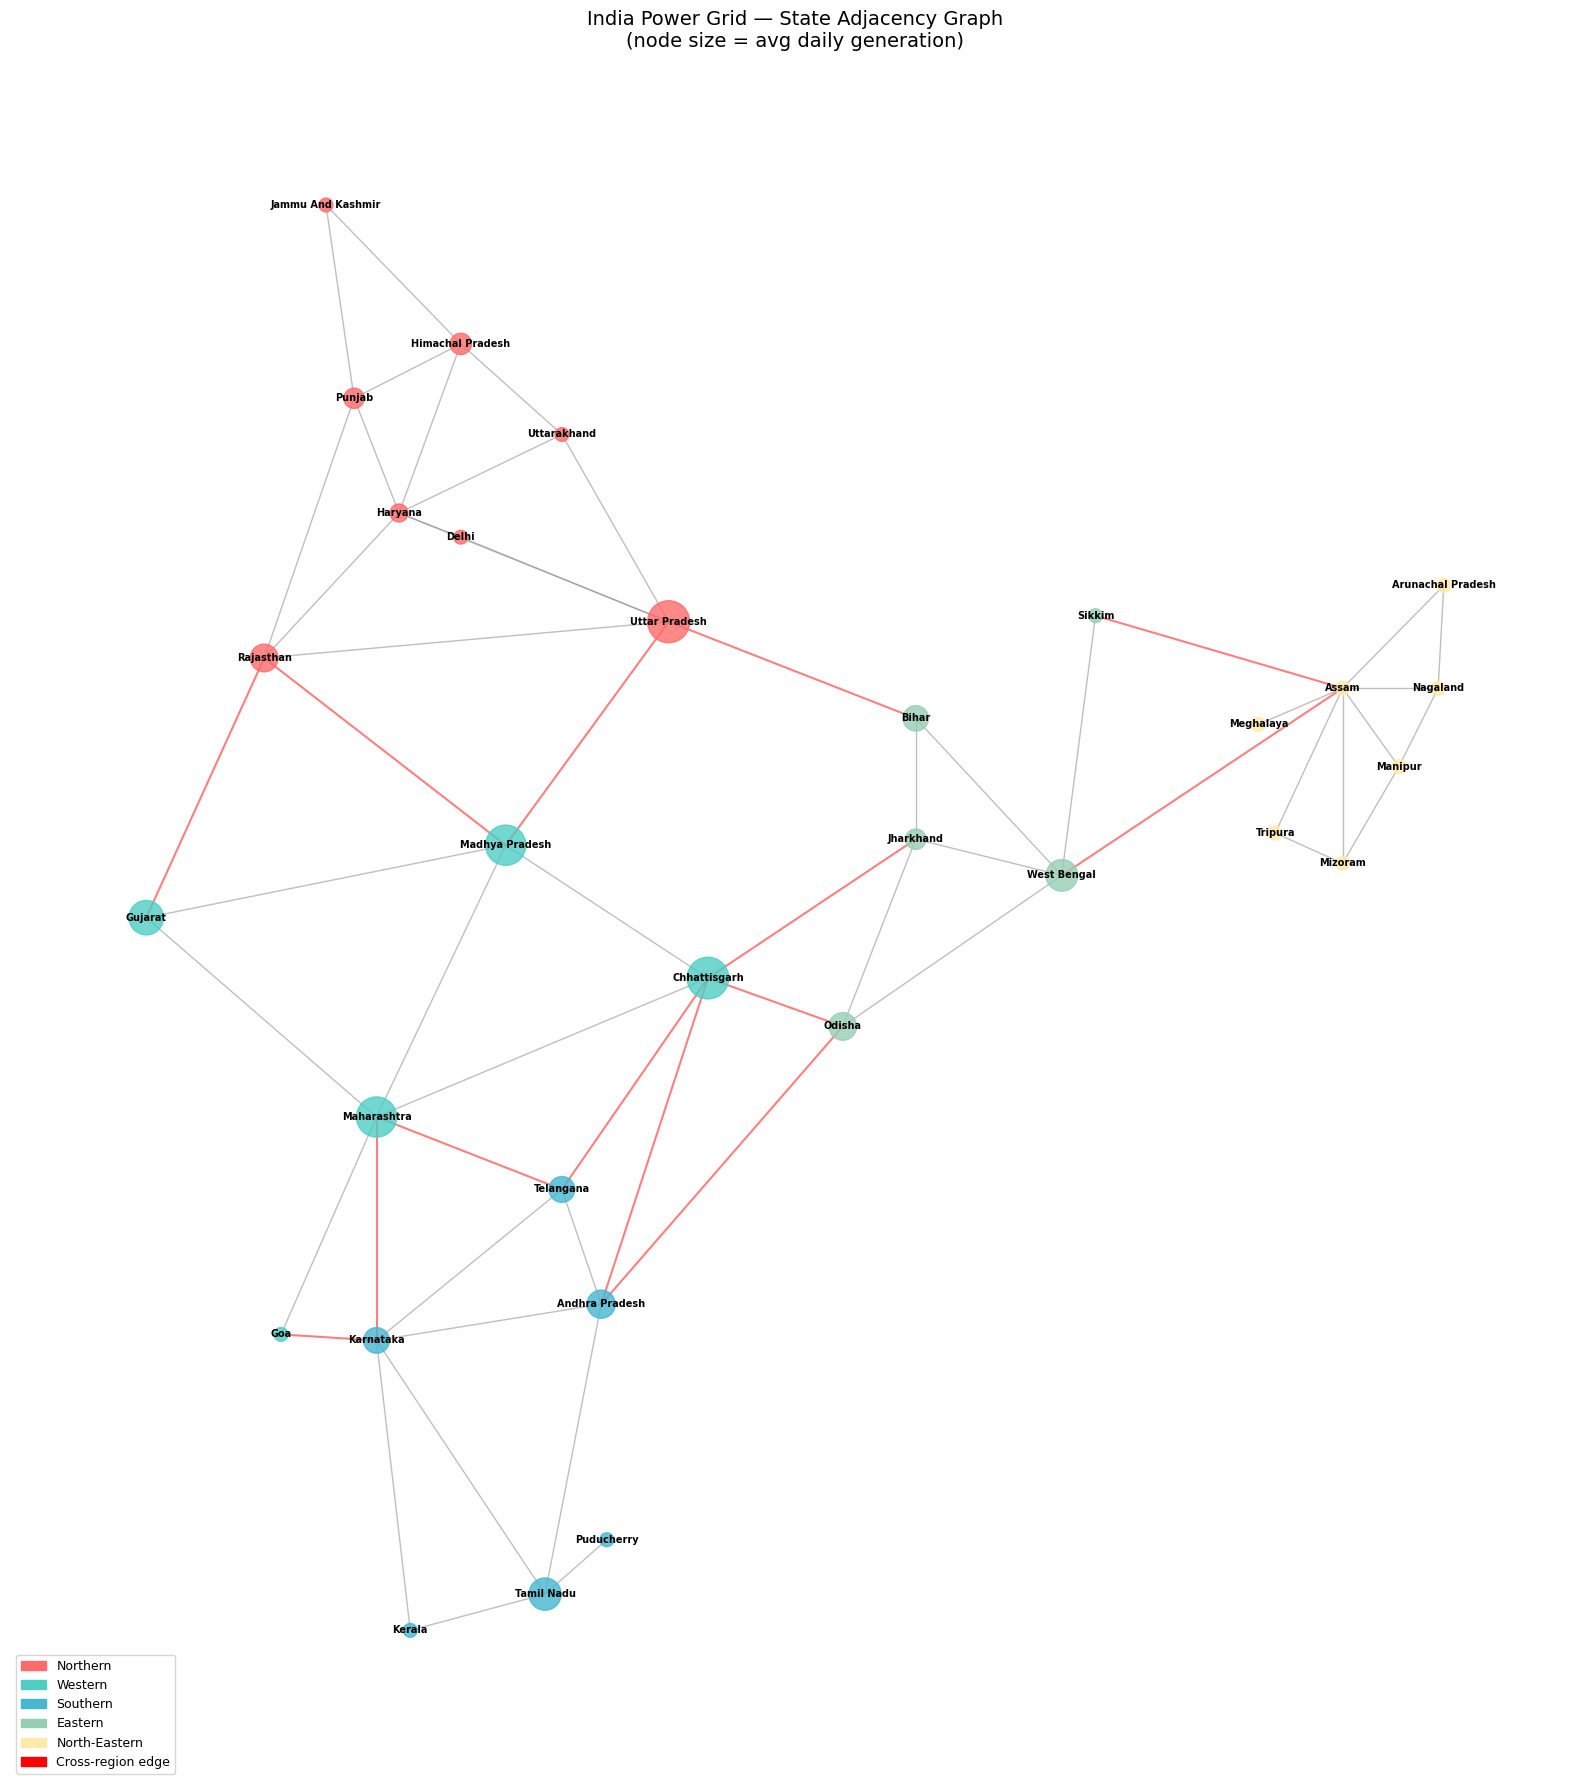

In [0]:
# Approximate lat/lon positions for Indian states (for visualization)
POS = {
    "Jammu And Kashmir": (74.8, 34.1),
    "Himachal Pradesh": (77.2, 31.8),
    "Punjab": (75.3, 30.9),
    "Chandigarh": (76.8, 30.7),
    "Uttarakhand": (79.0, 30.3),
    "Haryana": (76.1, 29.0),
    "Delhi": (77.2, 28.6),
    "Rajasthan": (73.7, 26.6),
    "Uttar Pradesh": (80.9, 27.2),
    "Bihar": (85.3, 25.6),
    "Jharkhand": (85.3, 23.6),
    "West Bengal": (87.9, 23.0),
    "Sikkim": (88.5, 27.3),
    "Odisha": (84.0, 20.5),
    "Chhattisgarh": (81.6, 21.3),
    "Madhya Pradesh": (78.0, 23.5),
    "Gujarat": (71.6, 22.3),
    "DNH And DD": (73.0, 20.4),
    "Maharashtra": (75.7, 19.0),
    "Goa": (74.0, 15.4),
    "Karnataka": (75.7, 15.3),
    "Telangana": (79.0, 17.8),
    "Andhra Pradesh": (79.7, 15.9),
    "Kerala": (76.3, 10.5),
    "Tamil Nadu": (78.7, 11.1),
    "Puducherry": (79.8, 12.0),
    "Assam": (92.9, 26.1),
    "Arunachal Pradesh": (94.7, 27.8),
    "Nagaland": (94.6, 26.1),
    "Manipur": (93.9, 24.8),
    "Mizoram": (92.9, 23.2),
    "Tripura": (91.7, 23.7),
    "Meghalaya": (91.4, 25.5),
}

# Color by grid region
REGION_COLORS = {
    "Northern": "#FF6B6B",
    "Western": "#4ECDC4",
    "Southern": "#45B7D1",
    "Eastern": "#96CEB4",
    "North-Eastern": "#FFEAA7",
}

fig, ax = plt.subplots(1, 1, figsize=(16, 18))

# Filter pos to only nodes in graph
pos = {n: POS[n] for n in G.nodes if n in POS}

# Node sizes proportional to avg generation
node_sizes = [max(G.nodes[n].get("avg_daily_gen", 10) * 2, 100) for n in G.nodes if n in pos]
node_colors = [REGION_COLORS.get(GRID_REGION.get(n, ""), "gray") for n in G.nodes if n in pos]

# Edge colors
edge_colors = ["red" if G.edges[e].get("cross_region") else "gray" for e in G.edges]
edge_widths = [1.5 if G.edges[e].get("cross_region") else 1.0 for e in G.edges]

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.5, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.8, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)

# Legend
patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
patches.append(mpatches.Patch(color="red", label="Cross-region edge"))
ax.legend(handles=patches, loc="lower left", fontsize=9)
ax.set_title("India Power Grid — State Adjacency Graph\n(node size = avg daily generation)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Surplus/Deficit Visualization on Graph

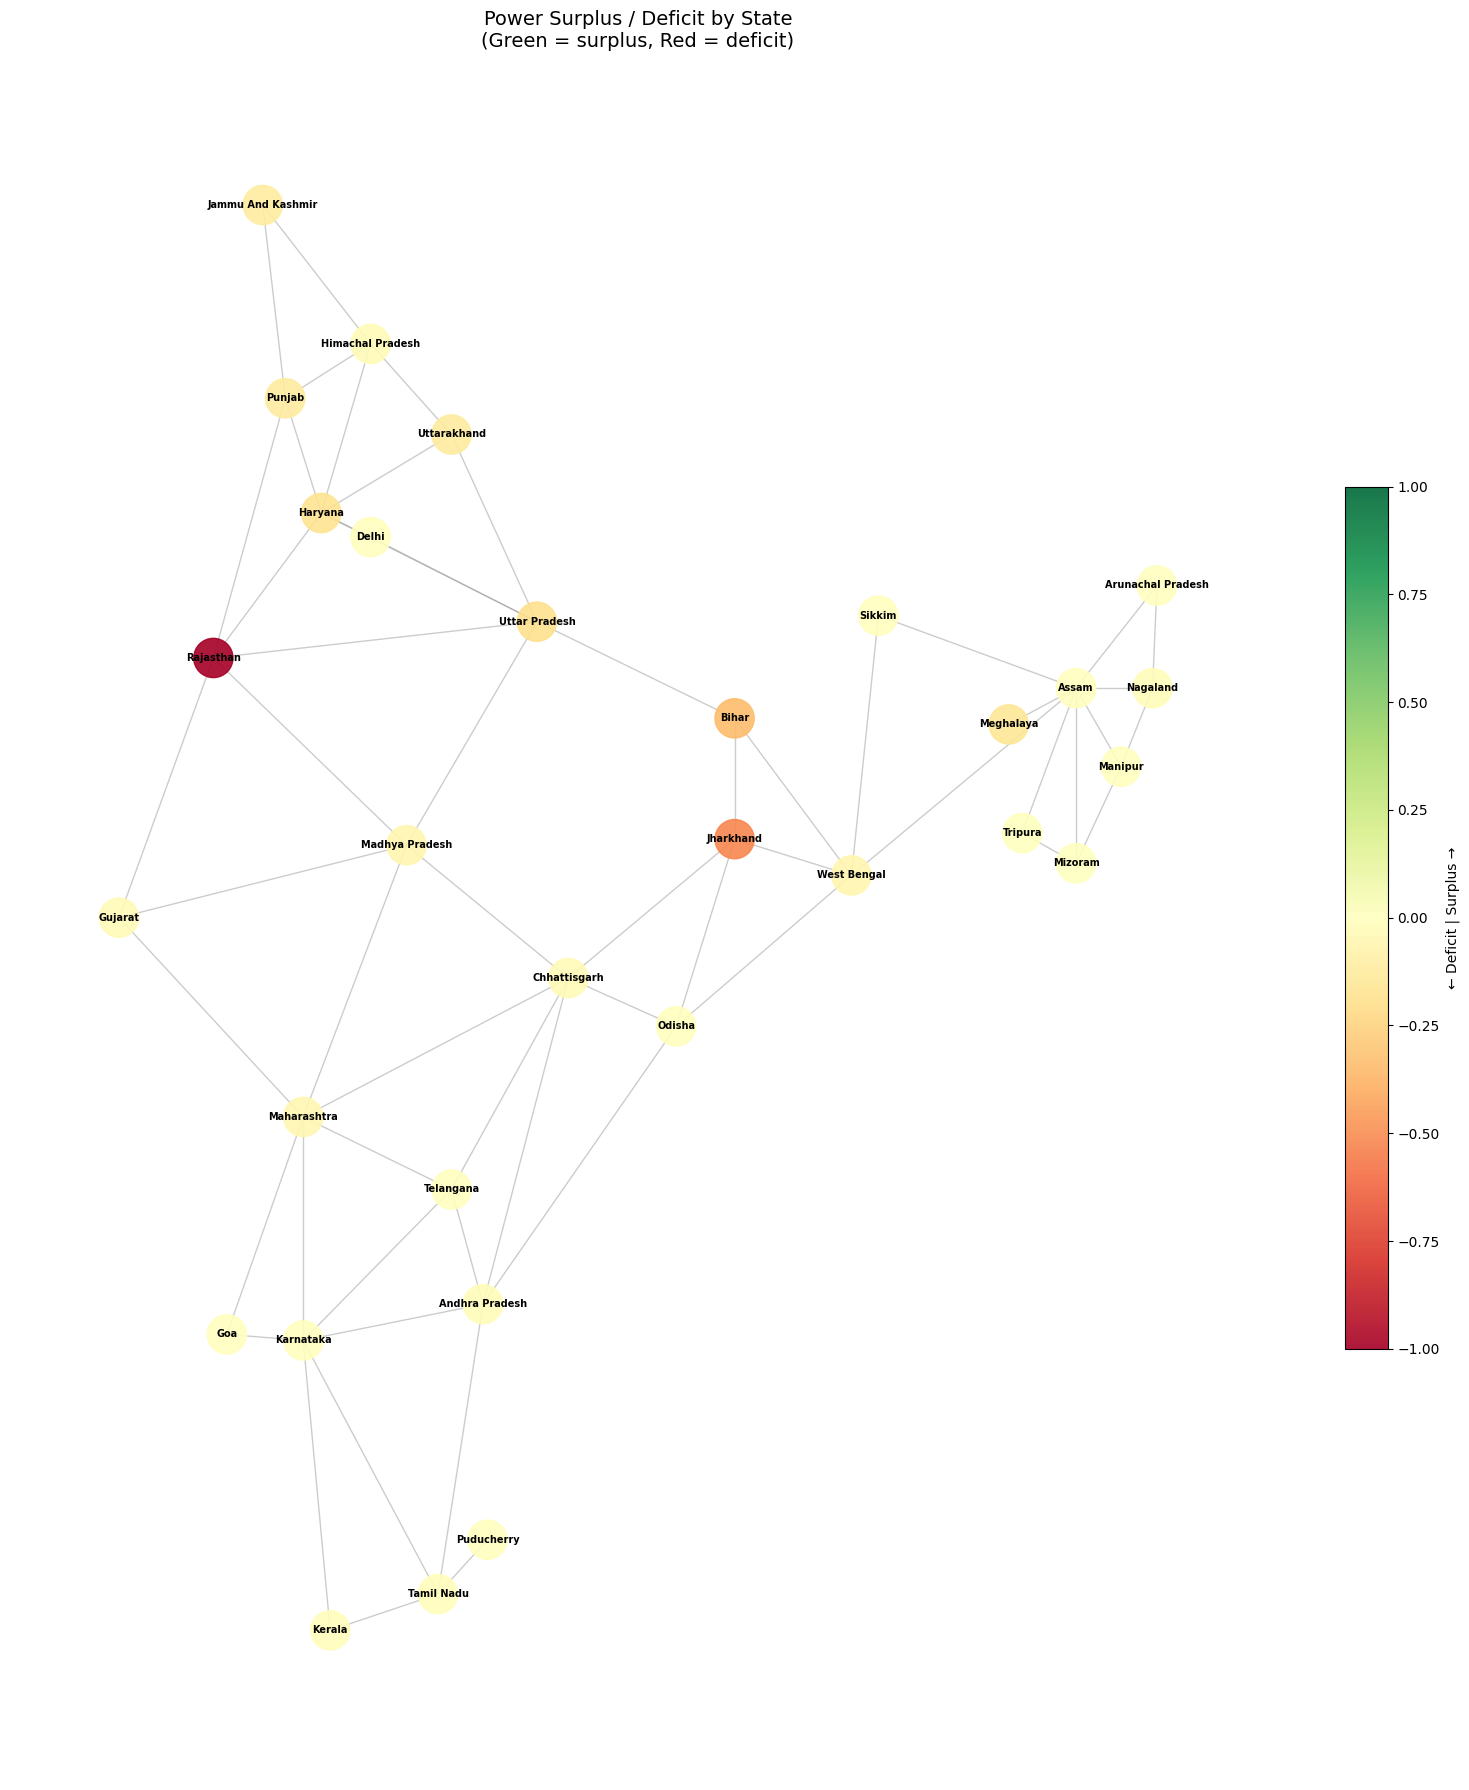

In [0]:
fig, ax = plt.subplots(1, 1, figsize=(16, 18))

# Color nodes by surplus (green) / deficit (red)
surplus_vals = [G.nodes[n].get("surplus_mu", 0) for n in G.nodes if n in pos]
max_abs = max(abs(min(surplus_vals)), abs(max(surplus_vals)), 1)

# Normalize to [-1, 1] for colormap
norm_surplus = [v / max_abs for v in surplus_vals]
cmap = plt.cm.RdYlGn  # Red = deficit, Green = surplus
node_colors_sd = [cmap(0.5 + v * 0.5) for v in norm_surplus]

nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.4, ax=ax)
nodes = nx.draw_networkx_nodes(G, pos, node_size=800, node_color=norm_surplus,
                                cmap=cmap, vmin=-1, vmax=1, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)

plt.colorbar(nodes, ax=ax, label="← Deficit | Surplus →", shrink=0.5)
ax.set_title("Power Surplus / Deficit by State\n(Green = surplus, Red = deficit)", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 7. 3-Hop Neighborhood Demo
Show which states can receive surplus power from a given state (max 3 edges away).

In [0]:
def get_k_hop_neighbors(G, source, k=3):
    """Get all nodes within k hops, organized by hop distance."""
    neighbors = {}
    visited = {source}
    current_layer = {source}
    
    for hop in range(1, k + 1):
        next_layer = set()
        for node in current_layer:
            for neighbor in G.neighbors(node):
                if neighbor not in visited:
                    next_layer.add(neighbor)
                    visited.add(neighbor)
        neighbors[hop] = next_layer
        current_layer = next_layer
    
    return neighbors

# Example: Maharashtra has surplus — who can it supply?
SOURCE = "Maharashtra"
hops = get_k_hop_neighbors(G, SOURCE, k=3)

print(f"\n{SOURCE} — 3-hop power distribution reach:")
for hop, states in hops.items():
    deficits = {s: G.nodes[s].get('surplus_mu', 0) for s in states}
    print(f"\n  Hop {hop} ({len(states)} states):")
    for s, d in sorted(deficits.items(), key=lambda x: x[1]):
        status = "DEFICIT" if d < 0 else "surplus"
        print(f"    {s}: {d:+.1f} MU ({status})")


Maharashtra — 3-hop power distribution reach:

  Hop 1 (6 states):
    Madhya Pradesh: -7.7 MU (DEFICIT)
    Gujarat: -4.8 MU (DEFICIT)
    Chhattisgarh: -3.9 MU (DEFICIT)
    Karnataka: -0.9 MU (DEFICIT)
    Telangana: -0.9 MU (DEFICIT)
    Goa: -0.0 MU (DEFICIT)

  Hop 2 (7 states):
    Rajasthan: -123.2 MU (DEFICIT)
    Jharkhand: -64.1 MU (DEFICIT)
    Uttar Pradesh: -23.5 MU (DEFICIT)
    Andhra Pradesh: -2.2 MU (DEFICIT)
    Tamil Nadu: -1.2 MU (DEFICIT)
    Kerala: -1.2 MU (DEFICIT)
    Odisha: -0.6 MU (DEFICIT)

  Hop 3 (7 states):
    Bihar: -41.6 MU (DEFICIT)
    Haryana: -21.8 MU (DEFICIT)
    Uttarakhand: -15.3 MU (DEFICIT)
    Punjab: -15.0 MU (DEFICIT)
    West Bengal: -7.6 MU (DEFICIT)
    Delhi: -0.8 MU (DEFICIT)
    Puducherry: -0.1 MU (DEFICIT)


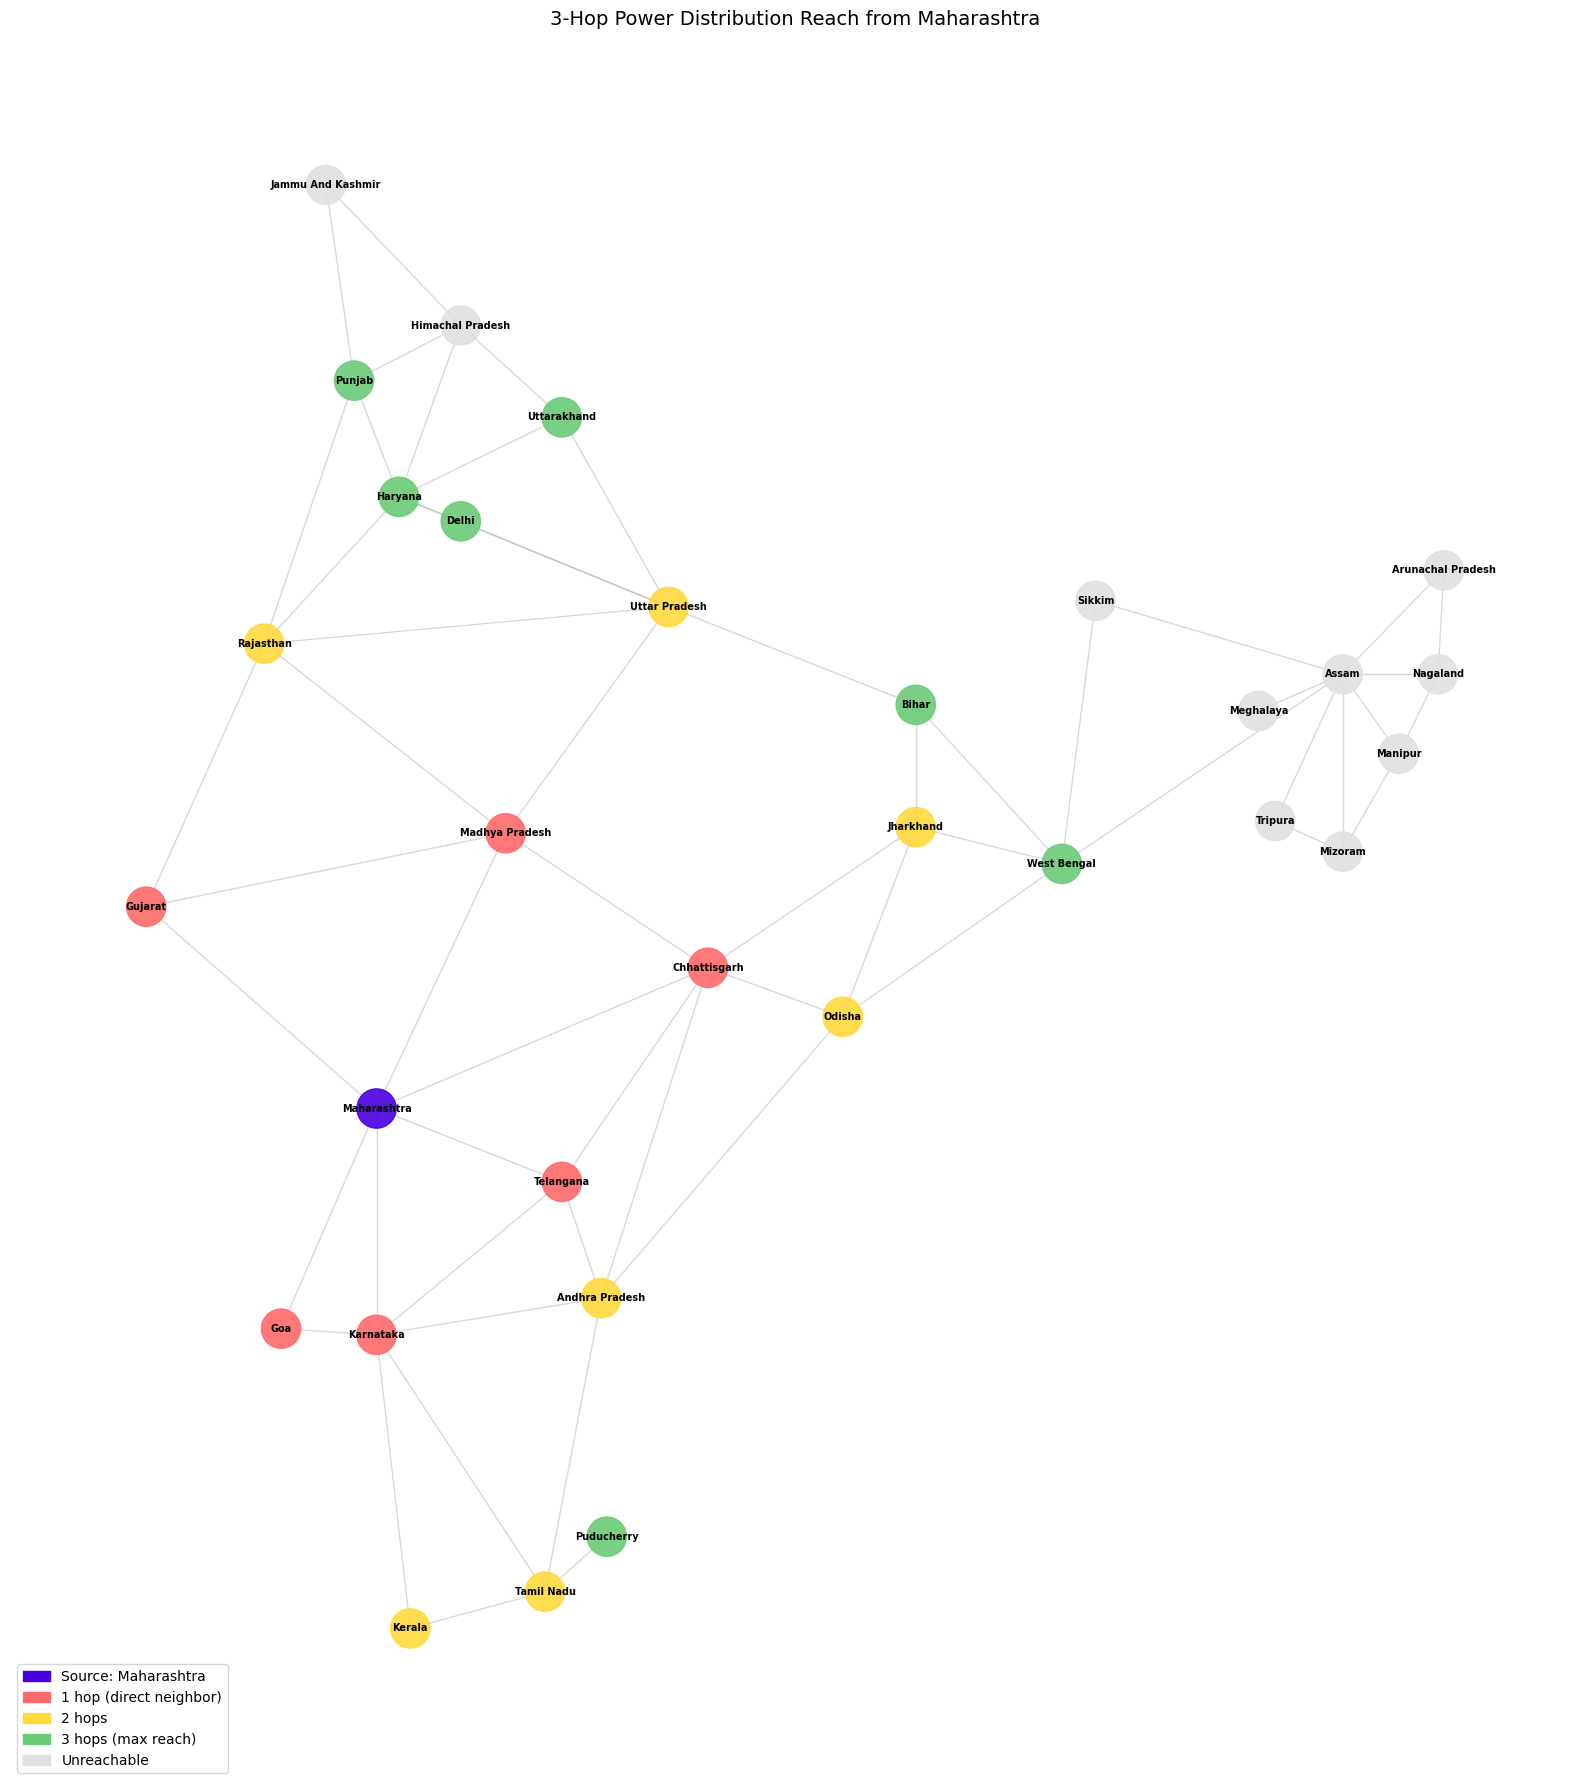

In [0]:
# Visualize 3-hop reach
HOP_COLORS = {1: "#FF6B6B", 2: "#FFD93D", 3: "#6BCB77"}

fig, ax = plt.subplots(1, 1, figsize=(16, 18))

# Default: gray for unreachable
node_colors = []
for n in G.nodes:
    if n == SOURCE:
        node_colors.append("#4A00E0")
    elif n in hops.get(1, set()):
        node_colors.append(HOP_COLORS[1])
    elif n in hops.get(2, set()):
        node_colors.append(HOP_COLORS[2])
    elif n in hops.get(3, set()):
        node_colors.append(HOP_COLORS[3])
    else:
        node_colors.append("#E0E0E0")

nx.draw_networkx_edges(G, pos, edge_color="gray", alpha=0.3, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight="bold", ax=ax)

patches = [
    mpatches.Patch(color="#4A00E0", label=f"Source: {SOURCE}"),
    mpatches.Patch(color=HOP_COLORS[1], label="1 hop (direct neighbor)"),
    mpatches.Patch(color=HOP_COLORS[2], label="2 hops"),
    mpatches.Patch(color=HOP_COLORS[3], label="3 hops (max reach)"),
    mpatches.Patch(color="#E0E0E0", label="Unreachable"),
]
ax.legend(handles=patches, loc="lower left", fontsize=10)
ax.set_title(f"3-Hop Power Distribution Reach from {SOURCE}", fontsize=14)
ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Export for PyG (GNN Notebook)
Convert NetworkX graph to format ready for PyTorch Geometric.

In [0]:
# Node ordering (fixed index for PyG)
node_list = sorted(G.nodes())
node_to_idx = {n: i for i, n in enumerate(node_list)}

# Feature columns for GNN (numeric only)
FEATURE_COLS = [
    "avg_daily_gen", "std_daily_gen", "avg_renewable",
    "total_capacity", "num_stations",
    "avg_demand", "avg_supply", "surplus_mu",
    "renewable_share", "capacity_utilization",
]

# Build feature matrix
X = np.zeros((len(node_list), len(FEATURE_COLS)))
for i, node in enumerate(node_list):
    for j, col in enumerate(FEATURE_COLS):
        X[i, j] = G.nodes[node].get(col, 0)

# Build edge index (PyG format: 2 x num_edges)
edge_index = []
edge_weights = []
for s1, s2, data in G.edges(data=True):
    i, j = node_to_idx[s1], node_to_idx[s2]
    edge_index.append([i, j])
    edge_index.append([j, i])  # undirected
    edge_weights.append(data.get("weight", 1.0))
    edge_weights.append(data.get("weight", 1.0))

edge_index = np.array(edge_index).T  # shape: (2, num_edges*2)
edge_weights = np.array(edge_weights)

# Target: surplus_mu (what the GNN learns to predict/redistribute)
y = np.array([G.nodes[n].get("surplus_mu", 0) for n in node_list])

print(f"Feature matrix X: {X.shape}")
print(f"Edge index: {edge_index.shape}")
print(f"Edge weights: {edge_weights.shape}")
print(f"Target y: {y.shape}")
print(f"\nFeature columns: {FEATURE_COLS}")
print(f"Node order: {node_list}")

# Save for GNN notebook
np.savez(
    "graph_data_for_gnn.npz",
    X=X, edge_index=edge_index, edge_weights=edge_weights, y=y,
)
pd.DataFrame({"idx": range(len(node_list)), "state": node_list}).to_csv("node_index.csv", index=False)
pd.DataFrame({"feature": FEATURE_COLS}).to_csv("feature_cols.csv", index=False)

print("\n✅ Saved: graph_data_for_gnn.npz, node_index.csv, feature_cols.csv")

Feature matrix X: (31, 10)
Edge index: (2, 116)
Edge weights: (116,)
Target y: (31,)

Feature columns: ['avg_daily_gen', 'std_daily_gen', 'avg_renewable', 'total_capacity', 'num_stations', 'avg_demand', 'avg_supply', 'surplus_mu', 'renewable_share', 'capacity_utilization']
Node order: ['Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']

✅ Saved: graph_data_for_gnn.npz, node_index.csv, feature_cols.csv
